# AI Credit Risk Assessment - Preprocessing & Modeling Pipeline

This notebook implements:
1. Loading the preprocessed training and scoring datasets.
2. Applying `RobustScaler` specifically to continuous numeric features.
3. Training and evaluating a baseline **Logistic Regression** and a main **XGBoost** model using 5-fold Stratified Cross-Validation.
4. Performing post-hoc probability calibration using Platt scaling.
5. Optimizing decision thresholds to maximize the F1 score.
6. Generating predictions for scoring companies and calculating feature contributions using **SHAP (Tree Explainer)**.


In [1]:
import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, auc, f1_score,
    precision_score, recall_score, brier_score_loss, confusion_matrix
)
import xgboost as xgb
import shap

# Set styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Imports and styling completed successfully.")


Imports and styling completed successfully.


In [2]:
# Define paths
DATA_DIR = "../data/processed"
os.makedirs(DATA_DIR, exist_ok=True)

# Load preprocessed datasets
train_df = pd.read_csv(os.path.join(DATA_DIR, "train_processed.csv"))
score_df = pd.read_csv(os.path.join(DATA_DIR, "scoring_processed.csv"))

# Separate features and target
X = train_df.drop(columns=["defaulted", "company_id"])
y = train_df["defaulted"]

X_score = score_df.drop(columns=["company_id"])
score_company_ids = score_df["company_id"]

print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"X_score shape: {X_score.shape}")


X shape: (1000, 50), y shape: (1000,)
X_score shape: (50, 50)


In [3]:
# Identify continuous vs. binary/encoded features
continuous_cols = [
    "revenue_m", "ebitda_margin", "debt_ratio", "interest_coverage",
    "cash_ratio", "years_in_operation", "employee_count", "revenue_growth",
    "distress_score", "debt_cov_profitability", "debt_to_earnings",
    "debt_to_coverage", "net_leverage", "debt_margin_stress", "liquidity_coverage"
]

# Get list of all other columns (which are binary indicators or one-hot encoded)
passthrough_cols = [col for col in X.columns if col not in continuous_cols]

# Build ColumnTransformer to scale only continuous features
preprocessor = ColumnTransformer(
    transformers=[
        ("num", RobustScaler(), continuous_cols),
        ("pass", "passthrough", passthrough_cols)
    ]
)

print(f"Preprocessor configured. Scaling {len(continuous_cols)} numeric features.")


Preprocessor configured. Scaling 15 numeric features.


In [4]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_predictions(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    
    # Calculate metrics
    roc_auc = roc_auc_score(y_true, y_prob)
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(recall, precision)
    
    f1 = f1_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred)
    
    # Confusion matrix to calculate False Positive Rate (FPR) and False Negative Rate (FNR)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
    
    # Calculate Brier score for probability quality check
    brier_score = brier_score_loss(y_true, y_prob)
    
    return {
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "f1": f1,
        "precision": prec,
        "recall": rec,
        "fpr": fpr,
        "fnr": fnr,
        "brier_score": brier_score
    }


In [5]:
print("=== Evaluating Logistic Regression Baseline ===")

fold_metrics_lr = []
oof_probs_lr = np.zeros(len(X))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # Fit scaler on training fold only
    X_train_scaled = preprocessor.fit_transform(X_train)
    X_val_scaled = preprocessor.transform(X_val)
    
    # Logistic Regression with balanced class weights
    model_lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
    model_lr.fit(X_train_scaled, y_train)
    
    # Predict default probabilities (class 1)
    probs = model_lr.predict_proba(X_val_scaled)[:, 1]
    oof_probs_lr[val_idx] = probs
    
    # Evaluate fold
    metrics = evaluate_predictions(y_val, probs)
    fold_metrics_lr.append(metrics)
    print(f"Fold {fold+1} - PR-AUC: {metrics['pr_auc']:.4f}, ROC-AUC: {metrics['roc_auc']:.4f}, F1: {metrics['f1']:.4f}")

# Compile baseline results
df_metrics_lr = pd.DataFrame(fold_metrics_lr)
print("\n--- Average Logistic Regression Baseline Metrics ---")
print(df_metrics_lr.mean())


=== Evaluating Logistic Regression Baseline ===
Fold 1 - PR-AUC: 0.4586, ROC-AUC: 0.7759, F1: 0.4464
Fold 2 - PR-AUC: 0.3673, ROC-AUC: 0.7688, F1: 0.4423
Fold 3 - PR-AUC: 0.4479, ROC-AUC: 0.6930, F1: 0.3636


Fold 4 - PR-AUC: 0.4782, ROC-AUC: 0.7702, F1: 0.4731


Fold 5 - PR-AUC: 0.5991, ROC-AUC: 0.8150, F1: 0.5192

--- Average Logistic Regression Baseline Metrics ---
roc_auc        0.764598
pr_auc         0.470206
f1             0.448944
precision      0.344984
recall         0.650252
fpr            0.259080
fnr            0.349748
brier_score    0.186184
dtype: float64


In [6]:
print("=== Tuning XGBoost Classifier ===")

# Calculate class imbalance multiplier (approx 4.75)
imbalance_ratio = (y == 0).sum() / (y == 1).sum()
print(f"Imbalance ratio (scale_pos_weight): {imbalance_ratio:.2f}")

# Define parameter grid for tuning
param_grid = {
    "max_depth": [3, 4, 5],
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [100, 150, 200],
    "subsample": [0.8],
    "colsample_bytree": [0.8]
}

# Apply scaler preprocessing globally to identify optimal parameters
X_scaled_global = preprocessor.fit_transform(X)

xgb_base = xgb.XGBClassifier(
    scale_pos_weight=imbalance_ratio,
    eval_metric="logloss",
    random_state=42
)

# Use Grid Search maximizing Average Precision (PR-AUC)
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring="average_precision",
    cv=skf,
    n_jobs=-1
)

grid_search.fit(X_scaled_global, y)
best_params = grid_search.best_params_
print(f"Best parameters found: {best_params}")


=== Tuning XGBoost Classifier ===
Imbalance ratio (scale_pos_weight): 4.75


Best parameters found: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


In [7]:
print("=== Evaluating Tuned XGBoost Classifier ===")

fold_metrics_xgb = []
oof_probs_xgb = np.zeros(len(X))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # Fit scaler on training fold only
    X_train_scaled = preprocessor.fit_transform(X_train)
    X_val_scaled = preprocessor.transform(X_val)
    
    # Instantiate best model
    model_xgb = xgb.XGBClassifier(
        **best_params,
        scale_pos_weight=imbalance_ratio,
        eval_metric="logloss",
        random_state=42
    )
    model_xgb.fit(X_train_scaled, y_train)
    
    # Predict probabilities
    probs = model_xgb.predict_proba(X_val_scaled)[:, 1]
    oof_probs_xgb[val_idx] = probs
    
    # Evaluate fold
    metrics = evaluate_predictions(y_val, probs)
    fold_metrics_xgb.append(metrics)
    print(f"Fold {fold+1} - PR-AUC: {metrics['pr_auc']:.4f}, ROC-AUC: {metrics['roc_auc']:.4f}, F1: {metrics['f1']:.4f}")

# Compile XGBoost results
df_metrics_xgb = pd.DataFrame(fold_metrics_xgb)
print("\n--- Average XGBoost Metrics ---")
print(df_metrics_xgb.mean())


=== Evaluating Tuned XGBoost Classifier ===
Fold 1 - PR-AUC: 0.4498, ROC-AUC: 0.7837, F1: 0.4615
Fold 2 - PR-AUC: 0.5161, ROC-AUC: 0.7967, F1: 0.5098


Fold 3 - PR-AUC: 0.4239, ROC-AUC: 0.7172, F1: 0.4048
Fold 4 - PR-AUC: 0.5011, ROC-AUC: 0.7790, F1: 0.4835
Fold 5 - PR-AUC: 0.5723, ROC-AUC: 0.8389, F1: 0.5647

--- Average XGBoost Metrics ---
roc_auc        0.783131
pr_auc         0.492656
f1             0.484865
precision      0.394689
recall         0.632605
fpr            0.204651
fnr            0.367395
brier_score    0.156960
dtype: float64


=== Probability Calibration Curve ===


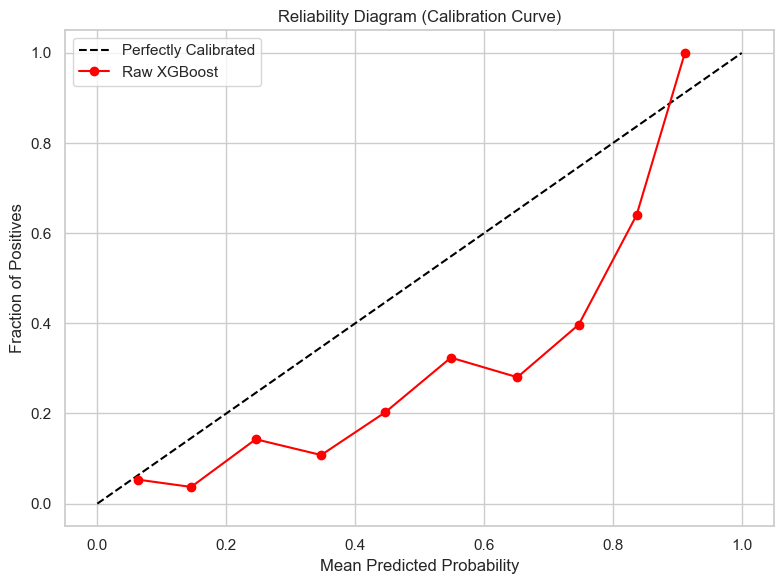

Raw XGBoost Brier Score Loss: 0.1570


In [8]:
print("=== Probability Calibration Curve ===")

# Plot reliability curves
prob_true_raw, prob_pred_raw = calibration_curve(y, oof_probs_xgb, n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfectly Calibrated", color="black")
plt.plot(prob_pred_raw, prob_true_raw, marker="o", label="Raw XGBoost", color="red")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Reliability Diagram (Calibration Curve)")
plt.legend()
plt.tight_layout()
plt.show()

# Calculate raw Brier score
brier_raw = brier_score_loss(y, oof_probs_xgb)
print(f"Raw XGBoost Brier Score Loss: {brier_raw:.4f}")


=== Training Calibrated Classifier ===



--- Average Calibrated XGBoost Metrics ---
roc_auc        0.788022
pr_auc         0.492494
f1             0.213337
precision      0.803333
recall         0.126218
fpr            0.007273
fnr            0.873782
brier_score    0.119156
dtype: float64


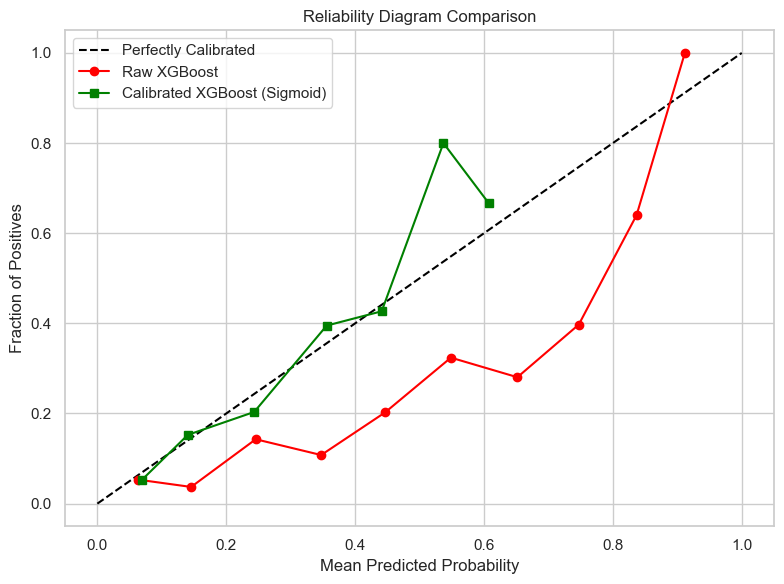

Calibrated XGBoost Brier Score Loss: 0.1192


In [9]:
print("=== Training Calibrated Classifier ===")

# Train scaling and calibration on K-Fold cross validation
# Using 'prefit' approach to calibrate a single estimator:
# Fit the preprocessor globally
X_scaled = preprocessor.fit_transform(X)

# Fit raw model
raw_xgb_model = xgb.XGBClassifier(
    **best_params,
    scale_pos_weight=imbalance_ratio,
    eval_metric="logloss",
    random_state=42
)

# Calibrated classifier CV using sigmoid (Platt Scaling)
calibrated_model = CalibratedClassifierCV(
    estimator=raw_xgb_model,
    method="sigmoid",
    cv=skf
)

calibrated_model.fit(preprocessor.transform(X), y)

# Predict calibrated probabilities out-of-fold/locally on CV
oof_probs_calibrated = np.zeros(len(X))
fold_metrics_cal = []
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    # Retrieve calibration using prefit on fold splits to get honest OOF probs
    X_tr, X_va = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]
    
    # Fit and calibrate
    X_tr_sc = preprocessor.fit_transform(X_tr)
    X_va_sc = preprocessor.transform(X_va)
    
    raw_fold = xgb.XGBClassifier(
        **best_params,
        scale_pos_weight=imbalance_ratio,
        eval_metric="logloss",
        random_state=42
    )
    cal_fold = CalibratedClassifierCV(estimator=raw_fold, method="sigmoid", cv=3)
    cal_fold.fit(X_tr_sc, y_tr)
    
    probs_cal = cal_fold.predict_proba(X_va_sc)[:, 1]
    oof_probs_calibrated[val_idx] = probs_cal
    
    # Evaluate fold
    metrics = evaluate_predictions(y_va, probs_cal)
    fold_metrics_cal.append(metrics)

# Compile Calibrated XGBoost results
df_metrics_cal = pd.DataFrame(fold_metrics_cal)
print("\n--- Average Calibrated XGBoost Metrics ---")
print(df_metrics_cal.mean())

# Plot calibrated reliability diagram
prob_true_cal, prob_pred_cal = calibration_curve(y, oof_probs_calibrated, n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfectly Calibrated", color="black")
plt.plot(prob_pred_raw, prob_true_raw, marker="o", label="Raw XGBoost", color="red")
plt.plot(prob_pred_cal, prob_true_cal, marker="s", label="Calibrated XGBoost (Sigmoid)", color="green")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Reliability Diagram Comparison")
plt.legend()
plt.tight_layout()
plt.show()

brier_cal = brier_score_loss(y, oof_probs_calibrated)
print(f"Calibrated XGBoost Brier Score Loss: {brier_cal:.4f}")


In [10]:
# Find the optimal threshold based on Calibrated Probabilities to maximize F1-score
precision, recall, thresholds = precision_recall_curve(y, oof_probs_calibrated)

# Remove the last threshold element (which is always 1)
thresholds_arr = thresholds
f1_scores = [2 * (p * r) / (p + r) if (p + r) > 0 else 0 for p, r in zip(precision[:-1], recall[:-1])]

best_idx = np.argmax(f1_scores)
optimal_threshold = thresholds_arr[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Optimal Threshold to maximize F1: {optimal_threshold:.4f} (Max F1: {best_f1:.4f})")

# Define Risk Tiers based on probabilities
def assign_risk_rating(prob, opt_threshold):
    # Low risk: Less than half the optimal threshold
    # High risk: Greater than or equal to the optimal threshold
    # Medium risk: In between
    if prob < (opt_threshold / 2):
        return "Low"
    elif prob < opt_threshold:
        return "Medium"
    else:
        return "High"

print("Risk tiering threshold logic set.")


Optimal Threshold to maximize F1: 0.2784 (Max F1: 0.4974)
Risk tiering threshold logic set.


In [11]:
# Preprocess scoring features
X_score_scaled = preprocessor.transform(X_score)

# Predict probabilities using final calibrated model ensemble
scoring_probs = calibrated_model.predict_proba(X_score_scaled)[:, 1]

# Create predictions dataframe
predictions_raw = pd.DataFrame({
    "company_id": score_company_ids,
    "predicted_default_probability": scoring_probs,
    "risk_rating": [assign_risk_rating(p, optimal_threshold) for p in scoring_probs]
})

print("Score Predictions (first 10):")
print(predictions_raw.head(10))

# Save raw predictions
predictions_raw.to_csv("../data/processed/predictions_raw.csv", index=False)
print("Saved predictions_raw.csv to data/processed/")


Score Predictions (first 10):
   company_id  predicted_default_probability risk_rating
0        1001                       0.133020         Low
1        1002                       0.362661        High
2        1003                       0.055588         Low
3        1004                       0.523833        High
4        1005                       0.537851        High
5        1006                       0.053502         Low
6        1007                       0.046957         Low
7        1008                       0.049124         Low
8        1009                       0.057216         Low
9        1010                       0.054204         Low
Saved predictions_raw.csv to data/processed/


=== Computing SHAP Explainability ===


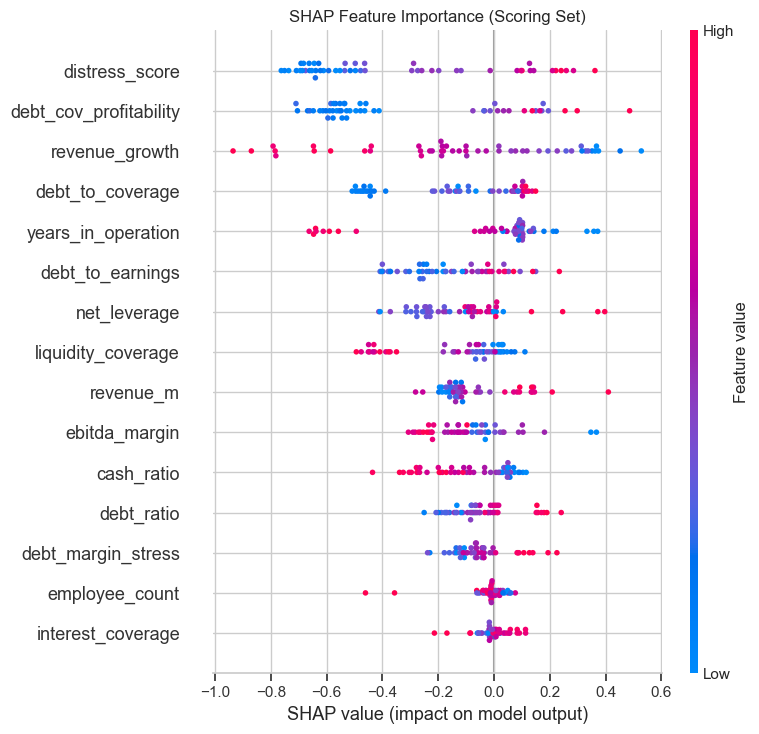

Saved shap_values.pkl to data/processed/


In [12]:
print("=== Computing SHAP Explainability ===")

# TreeExplainer requires the raw XGBoost model, not the CalibratedClassifierCV wrapper.
# Since calibrated_model is fit using CV (which has a list of estimators),
# we fit one single raw model on the entire scaled dataset for our TreeExplainer.
raw_model_final = xgb.XGBClassifier(
    **best_params,
    scale_pos_weight=imbalance_ratio,
    eval_metric="logloss",
    random_state=42
)
raw_model_final.fit(preprocessor.transform(X), y)

# Initialize SHAP TreeExplainer
explainer = shap.TreeExplainer(raw_model_final)

# Calculate SHAP values for the scoring set (use scaled features)
shap_values = explainer(X_score_scaled)

# Store original column names for interpretability in SHAP plots
# We reconstruct the feature names array from column transformer
feature_names = continuous_cols + passthrough_cols
shap_values.feature_names = feature_names

# Plot SHAP summary plot (bar chart of overall feature importance)
shap.summary_plot(shap_values, max_display=15, show=False)
plt.title("SHAP Feature Importance (Scoring Set)")
plt.tight_layout()
plt.show()

# Serialize SHAP values and explainer object for prompt injection
shap_data = {
    "shap_values": shap_values.values,
    "base_values": shap_values.base_values,
    "feature_names": feature_names,
    "scoring_features_scaled": X_score_scaled,
    "scoring_features_raw": X_score.values
}

with open("../data/processed/shap_values.pkl", "wb") as f:
    pickle.dump(shap_data, f)
    
print("Saved shap_values.pkl to data/processed/")
